# Stock Prediction

## Data and Packages

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv('C:/Users/Judit/Desktop/hw/25_26/Project/data/all_stocks_5yr/all_stocks_5yr.csv')

In [3]:
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [4]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name'], dtype='object')

Open - price of the stock at market open (USD)

High - highest price reached in the day

Low Close - lowest price reached in the day

Volume - number of shares traded

Name - ticker of stocks

Revenue -> negyed évente

earning

roa, roe
market cap-es adatok 

stacionáris modellek végig -> időben llandóak
nem árat modellezik, log-return -> hozam (mai close/tegnapi logaritmusa) -> stacionáriusak végül

!!! log hozamokra -> arima modell arma
holnapikimenet, az előők kombinációja
kimenet + zaj -> múltbélki zaok pl (y, y1, y2 ; epszilon, n -> zaj)
korrelálatlanok -> fehér zaj ?
függetlenek a zajok?

!!! aic meg bic kritérium? b, q -> ez az esetek száma, visszatekintve mennyi esetet nézzen 
legkissebb négyzetes becslés (fi, teta-t ad, akkor xt-re mennyire lesznek távol a megfigyelt dologtól) első körben -> paraméter nézet -> négyzetes eltérés minimalizálása

!!! ARMAX modell -> x (u) magyarázó változó. Pl nálunk earning, stb ->

!!! gauss process arx -> valószínűségi előrejelzés


!!! kategorizálás -> különböző végek különböző csoportokba kerüljenek és a modellek úgy kerüljenek rá (Coca-cola meg egy banking cég nem ugyanúgy működik)

végén -> epszilon saját generálás forcasting jövőre; 
konfidencia halmaz (?) 

Kövi konzultációra
- log hozamos
- revenues adat -> normalizálva, market - capre leosztva (összehasonlítható változó); operating margin etc skálafüggetlen paraméterek
- arima modell
- Cég csoportok keresése
- aic, bic összehasonlítása (hasonló eredmény)


In [5]:
df.describe()

,open,high,low,close,volume
count,619029.000000,619032.000000,619032.000000,619040.000000,6.190400e+05
mean,83.023334,83.778311,82.256096,83.043763,4.321823e+06
std,97.378769,98.207519,96.507421,97.389748,8.693610e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,40.220000,40.620000,39.830000,40.245000,1.070320e+06
50%,62.590000,63.150000,62.020000,62.620000,2.082094e+06
75%,94.370000,95.180000,93.540000,94.410000,4.284509e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [14]:
df['Name'].nunique()

505

In [16]:
df['date'].min()

'2013-02-08'

In [17]:
df['date'].max()

'2018-02-07'

## AAL checking

In [6]:
example_ticker = df[df['Name'] == 'AAL']

In [7]:
#plt.figure(figsize=(18, 5))

#plt.subplot(1, 2, 1)
#sns.barplot('date', 'open', hue ='date', data = example_ticker)
#plt.title('AAL Open Price')

#plt.subplot(1, 2, 1)
#sns.barplot('date', 'open', hue ='date', data = example_ticker)
#plt.title('AAL Close Price')

Inedxing and Closing data filter

In [8]:
example_ticker['date'] = pd.to_datetime(example_ticker['date'])
example_ticker = example_ticker.sort_values('date')
example_ticker.set_index('date', inplace=True)

c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [9]:
ts = example_ticker['close']

## ARIMA

Parameter findings

In [10]:
model_auto = auto_arima(ts, seasonal=False, trace=True)
order = model_auto.order

print(model_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=3212.973, Time=1.04 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3212.261, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3208.962, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3209.245, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3211.684, Time=0.04 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=3210.192, Time=0.19 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3210.554, Time=0.19 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=3211.797, Time=0.66 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=3208.210, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=3209.380, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=3209.761, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=3208.511, Time=0.07 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=3211.060, Time=0.73 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0]          
Total fit time: 3.559 seconds
                      

Tran and test data splitting

In [11]:
split_index = int(len(ts) * 0.7)

train = ts[:split_index]
test = ts[split_index:]

model = ARIMA(train, order=order)
model_fit = model.fit()
print(model_fit.summary())

                             ARIMA Model Results                              
Dep. Variable:                D.close   No. Observations:                  880
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -1123.540
Method:                       css-mle   S.D. of innovations              0.867
Date:                Thu, 19 Mar 2026   AIC                           2253.080
Time:                        15:36:35   BIC                           2267.420
Sample:                             1   HQIC                          2258.564
                                                                              
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0222      0.032      0.701      0.483      -0.040       0.084
ar.L1.D.close     0.0780      0.034      2.321      0.020       0.012       0.144
                                    Root

c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\arima_model.py:472: FutureWarning: 
statsmodels.tsa.arima_model.ARMA and statsmodels.tsa.arima_model.ARIMA have
been deprecated in favor of statsmodels.tsa.arima.model.ARIMA (note the .
between arima and model) and
statsmodels.tsa.SARIMAX. These will be removed after the 0.12 release.

statsmodels.tsa.arima.model.ARIMA makes use of the statespace framework and
is both well tested and maintained.

To silence this warning and continue using ARMA and ARIMA until they are
removed, use:

import warnings
warnings.filterwarnings('ignore', 'statsmodels.tsa.arima_model.ARMA',
                        FutureWarning)
warnings.filterwarnings('ignore', 'statsmodels.tsa.arima_model.ARIMA',
                        FutureWarning)

  warnings.warn(ARIMA_DEPRECATION_WARN, FutureWarning)
c:\users\judit\appdata\local\programs\python\python37\lib\site-packages\statsmodels\tsa\base\tsa_model.py:583: ValueWarning: A date i

Forcast and visualisation

70.95355016118296


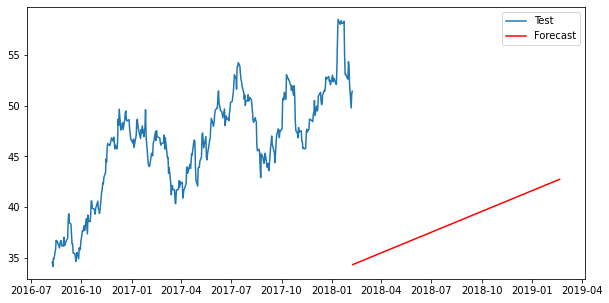

In [13]:
forecast, stderr, conf_int = model_fit.forecast(steps=len(test))

forecast = pd.Series(forecast)
forecast_index = pd.date_range(start=test.index[-1], periods=379, freq='D')[1:]
forecast.index = forecast_index
print(mean_squared_error(test, forecast))

plt.figure(figsize=(10,5))
#plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.show()